# 데이터 불러오기와 EDA 

In [2]:
import pandas as pd 
df = pd.read_csv("data/accepted_2007_to_2018Q4.csv")

C:\Users\didwn\AppData\Local\Temp\ipykernel_22804\506203059.py:2: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/accepted_2007_to_2018Q4.csv")


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("로드 완료")
print("=" * 60)

로드 완료


# EDA
- 분석 컬럼만 추출
- 완납을 0으로 부도를 1 로 설정

In [ ]:
# 종속 변수 추출

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [149]:
# 데이터 추출 후보들 
#df_eda = df.loc[(df["target"] == 0) |
#             (df["target"] == 1), 
#             ["loan_amnt", "term", "int_rate","installment","grade","sub_grade", "issue_d", 
#              "purpose", "target", "application_type"]
#             ] 

In [5]:
# 매핑 , 완납을 0으로 부도를 1 로 설정
status_map = { 
    "Fully Paid" : 0 ,
    "Charged Off" :1, 
    "Default" : 1
}

df["target"] = df["loan_status"].map(status_map)
df["target"].value_counts()
df= df.loc[df["target"].notnull()].copy()

In [151]:
y = df.loc[(df["target"] == 0) |
             (df["target"] == 1)] 

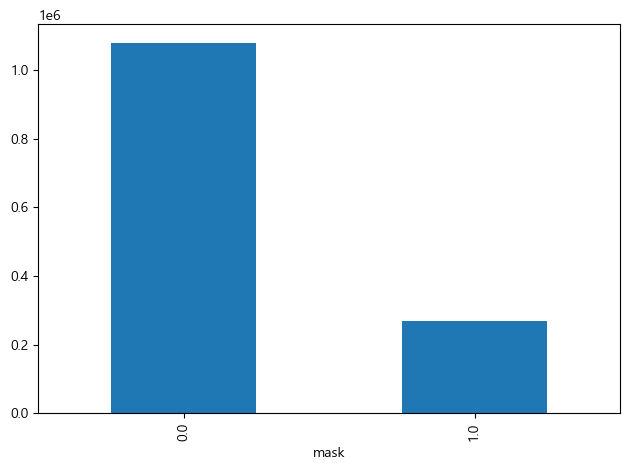

In [108]:
import matplotlib.pyplot as plt

# 기본 막대 그래프
df["target"].value_counts().plot(kind="bar")
plt.tight_layout()
plt.show()

# 단일 변수별 종속 변수의 움직임을 확인

,mask,mean,median,std,count
0,0.0,14124.637238,12000.0,8668.035712,1078739
1,1.0,15547.994765,14300.0,8814.499297,269320


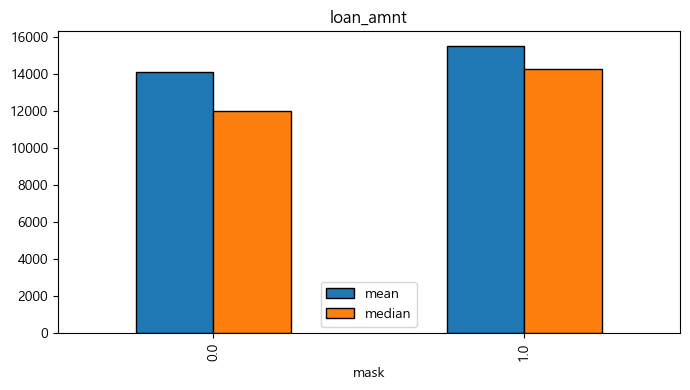

In [7]:
# loan_amnt 대출 금액 
eda_1 = df.loc[(df["target"] == 0) |
             (df["target"] == 1), ["loan_amnt", "target"]] 

g_result = eda_1.groupby("target")["loan_amnt"].agg(
    mean = "mean", 
    median="median",
    std="std",
    count="count"
).reset_index()
display(g_result)


g_result.plot(
    kind="bar", 
    x= "target", 
    y= ["mean","median"],
    figsize=(7, 4),
    edgecolor="black"
)
plt.title("loan_amnt")
plt.tight_layout()
plt.show()

# 부도쪽이 대출 금액이 상대적으로 크다. 
# 가설: 그룹별 대출 금액의 차이가 있는가 ?

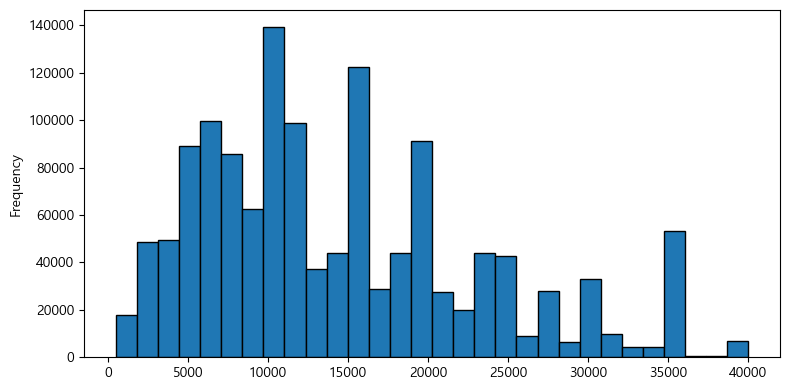

In [104]:
# bins, 컬러 조정
eda_1["loan_amnt"].plot(kind="hist", bins=30, edgecolor="black", figsize=(8, 4))
plt.tight_layout()
plt.show()
# 양의 왜도 형태 

,term_clean,mask,count
0,36,0.0,859280
1,36,1.0,163901
2,60,0.0,219459
3,60,1.0,105419


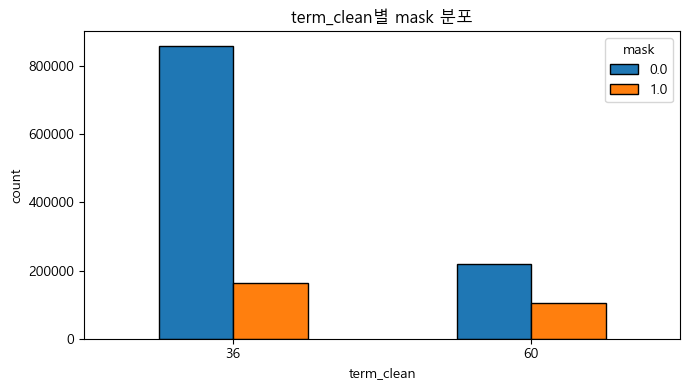

In [8]:
# term 대출 기간
eda_2 = df.loc[(df["target"] == 0) |
             (df["target"] == 1), ["term", "target"]] 

term_to_num= (
    df["term"].astype("string")
    .str.strip()
    .str.replace("months","", regex=False)
)

eda_2["term_clean"]= pd.to_numeric(term_to_num, errors="coerce")
eda_2 = eda_2.drop(columns="term")

g_result = eda_2.groupby(["term_clean", "target"]).size().reset_index(name="count")

display(g_result)

pivot = g_result.pivot(index="term_clean", columns="target", values="count")

pivot.plot(
    kind="bar",
    figsize=(7, 4),
    edgecolor="black"
)
plt.title("term_clean별 target 분포")
plt.xlabel("term_clean")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.legend(title="target")
plt.tight_layout()

# 대출을 완납한 경우는 36 개월 비율이 앞도적으로 많다. 3년과 5년 옵션
# 그리고 term은 3년 5년이니까 변환 과정 없이 그대로 문자열로 사용하면될듯 
# 오히려 숫자형이면 바이어스가 발생할 것

### 전반적으로 추적해볼 필요가 있음 
- 사용 컬럼들 

,pymnt_plan,mask,count
0,n,0.0,1078739
1,n,1.0,269320


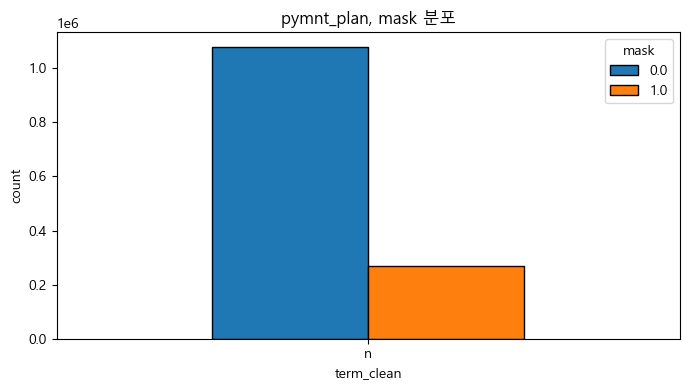

In [28]:
# pymnt_plan
eda_2 = df.loc[(df["target"] == 0) |
             (df["target"] == 1), ["pymnt_plan", "target"]] 



g_result = eda_2.groupby(["pymnt_plan", "target"]).size().reset_index(name="count")

display(g_result)

pivot = g_result.pivot(index="pymnt_plan", columns="target", values="count")

pivot.plot(
    kind="bar",
    figsize=(7, 4),
    edgecolor="black"
)
plt.title("pymnt_plan, target 분포")
plt.xlabel("term_clean")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.legend(title="target")
plt.tight_layout()

In [35]:
df["title"]

0          Debt consolidation
1                    Business
2                         NaN
3          Debt consolidation
4              Major purchase
                  ...        
2260696                   NaN
2260697    Debt consolidation
2260698                   NaN
2260699                   NaN
2260700                   NaN
Name: title, Length: 2260701, dtype: str

,application_type,mask,count
0,Individual,0.0,1059283
1,Individual,1.0,262976
2,Joint App,0.0,19456
3,Joint App,1.0,6344


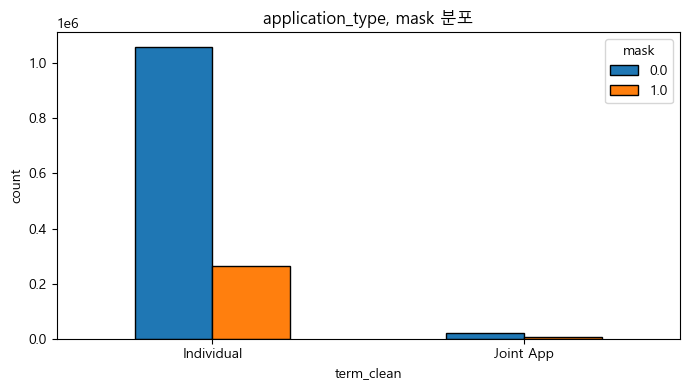

In [100]:
# application_type

g_result = df.groupby(["application_type", "target"]).size().reset_index(name="count")

display(g_result)

pivot = g_result.pivot(index="application_type", columns="target", values="count")

pivot.plot(
    kind="bar",
    figsize=(7, 4),
    edgecolor="black"
)
plt.title("application_type, target 분포")
plt.xlabel("term_clean")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.legend(title="target")
plt.tight_layout()

# 개인이 압도적으로 많음

In [128]:
df["emp_title"].value_counts().head(10)
df["emp_title"].isnull().sum()


np.int64(85944)

,emp_yes,mask,count
0,n,0.0,63433
1,n,1.0,22511
2,y,0.0,1015306
3,y,1.0,246809


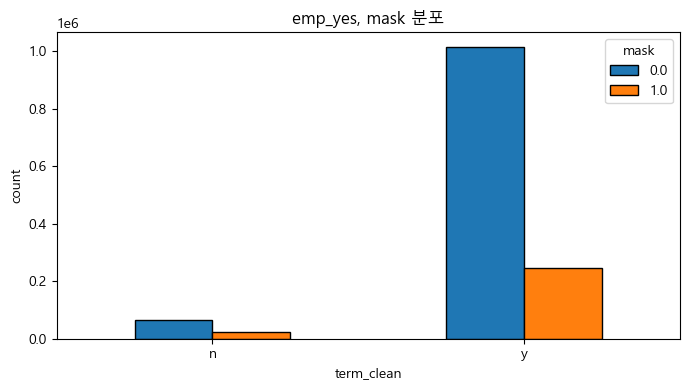

In [124]:
#차입자의 직함 존재 여부에 따른 y 
df_eda["emp_yes"] = np.where(df["emp_title"].isnull(), "n", "y")
# 확인
df_eda["emp_yes"].value_counts()

g_result = df_eda.groupby(["emp_yes", "target"]).size().reset_index(name="count")

display(g_result)

pivot = g_result.pivot(index="emp_yes", columns="target", values="count")

pivot.plot(
    kind="bar",
    figsize=(7, 4),
    edgecolor="black"
)
plt.title("emp_yes, target 분포")
plt.xlabel("term_clean")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.legend(title="target")
plt.tight_layout()

# 큰 차이는 없어 보임

,home_ownership,mask,count
0,ANY,0.0,230
1,ANY,1.0,56
2,MORTGAGE,0.0,551956
3,MORTGAGE,1.0,114879
4,NONE,0.0,45
5,NONE,1.0,8
6,OTHER,0.0,144
7,OTHER,1.0,38
8,OWN,0.0,115106
9,OWN,1.0,29913


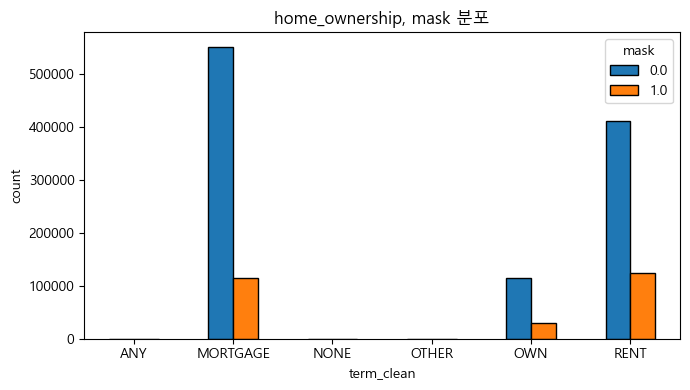

In [130]:
g_result = df.groupby(["home_ownership", "target"]).size().reset_index(name="count")

display(g_result)

pivot = g_result.pivot(index="home_ownership", columns="target", values="count")

pivot.plot(
    kind="bar",
    figsize=(7, 4),
    edgecolor="black"
)
plt.title("home_ownership, target 분포")
plt.xlabel("term_clean")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.legend(title="target")
plt.tight_layout()
# 주거 소유별로 부도 비율이 다른가? 

,mask,mean,median,std,count
0,0.0,77695.718632,65000.0,70935.617896,1078735
1,1.0,70398.271338,60000.0,65385.813572,269320


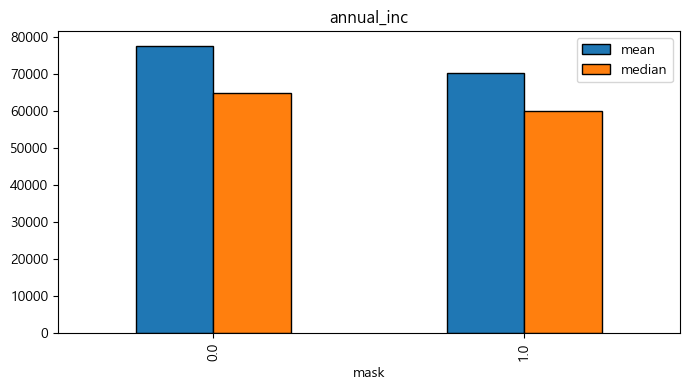

In [131]:
# annual_inc 

g_result = df.groupby("target")["annual_inc"].agg(
    mean = "mean", 
    median="median",
    std="std",
    count="count"
).reset_index()
display(g_result)


g_result.plot(
    kind="bar", 
    x= "target", 
    y= ["mean","median"],
    figsize=(7, 4),
    edgecolor="black"
)
plt.title("annual_inc")
plt.tight_layout()
plt.show()

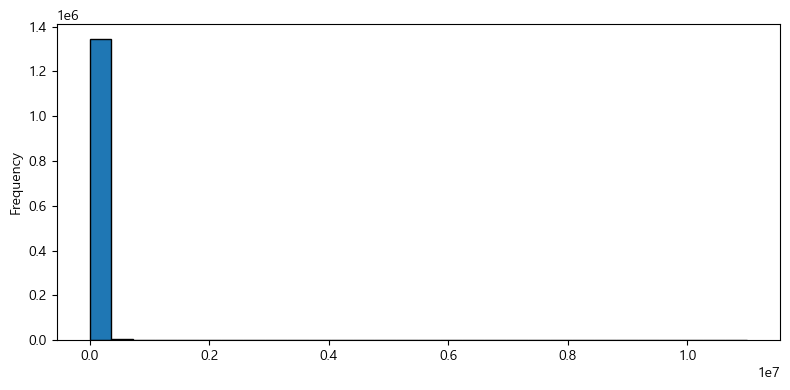

In [135]:
df["annual_inc"].plot(kind="hist", bins=30, edgecolor="black", figsize=(8, 4))
plt.tight_layout()
plt.show()

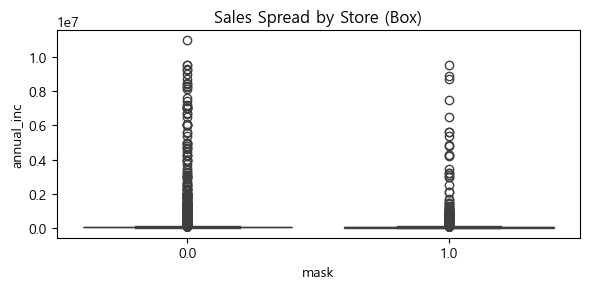

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
sns.boxplot(data=df, x="target", y="annual_inc")
plt.title("Sales Spread by Store (Box)")
plt.tight_layout()
plt.show()

# 연간 소득은 극단값이 많이 들어가있음

,verification_status,mask,count
0,Not Verified,0.0,347487
1,Not Verified,1.0,60046
2,Source Verified,0.0,412249
3,Source Verified,1.0,109314
4,Verified,0.0,319003
5,Verified,1.0,99960


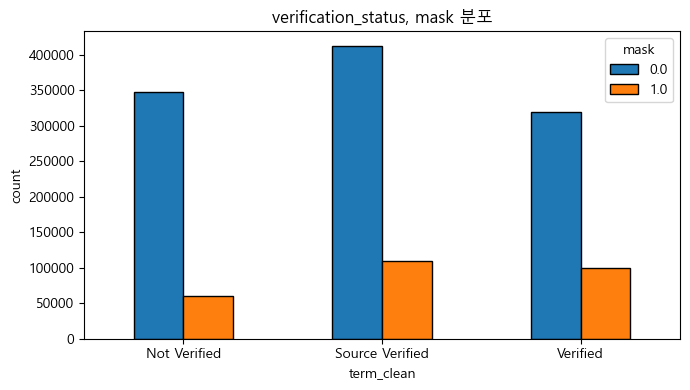

In [137]:
# 소득 검증 상태 별로 다른가? 
g_result = df.groupby(["verification_status", "target"]).size().reset_index(name="count")

display(g_result)

pivot = g_result.pivot(index="verification_status", columns="target", values="count")

pivot.plot(
    kind="bar",
    figsize=(7, 4),
    edgecolor="black"
)
plt.title("verification_status, target 분포")
plt.xlabel("term_clean")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.legend(title="target")
plt.tight_layout()

51


,addr_state,target,count
0,AK,0,2563
1,AK,1,627
2,AL,0,12687
3,AL,1,3926
4,AR,0,7627
...,...,...,...
97,WI,1,3254
98,WV,0,4121
99,WV,1,757
100,WY,0,2432


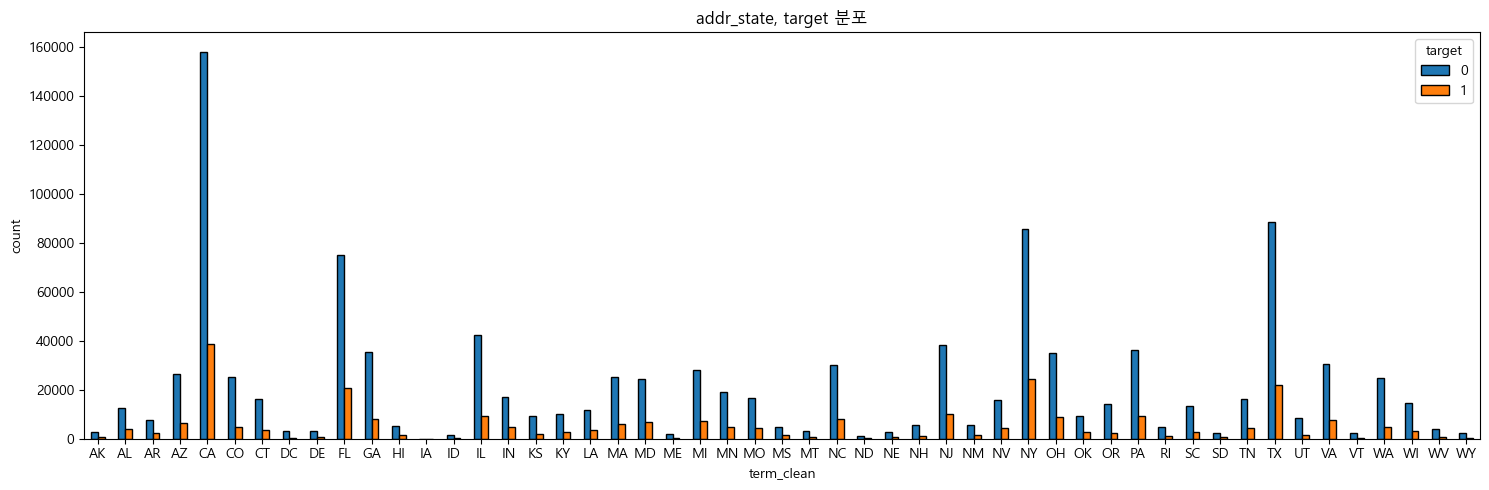

In [152]:
# 지역 코드 별로 다른가? 
print(df["addr_state"].nunique())

g_result = df.groupby(["addr_state", "target"]).size().reset_index(name="count")

display(g_result)
pivot = g_result.pivot(index="addr_state", columns="target", values="count")

pivot.plot(
    kind="bar",
    figsize=(15, 5),
    edgecolor="black"
)
plt.title("addr_state, target 분포")
plt.xlabel("term_clean")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.legend(title="target")
plt.tight_layout()

# 범주가 많네 
# 하지만 차이는 있어 보임 
# 지역별로 다른가? 
# 너무 많은데 

### 지역 변수에 대한 파생 피쳐 생성 
### 경제 규모 기반 (GDP / 대출 볼륨)
### Census 권역 매핑 

- Tier 1 (대출 최다)  — CA, TX, NY, FL
- Tier 2 (중상위)     — IL, PA, OH, GA, NJ, NC, VA
- Tier 3 (중위)       — 나머지
- Tier 4 (소규모)     — 대출 건수 매우 적은 주 (WY, ND, SD, VT 등)



,new_regin,purpose,count
0,Tier1_대규모,car,5995
1,Tier1_대규모,credit_card,123470
2,Tier1_대규모,debt_consolidation,322581
3,Tier1_대규모,educational,141
4,Tier1_대규모,home_improvement,35882
5,Tier1_대규모,house,3244
6,Tier1_대규모,major_purchase,12788
7,Tier1_대규모,medical,6608
8,Tier1_대규모,moving,4731
9,Tier1_대규모,other,35402


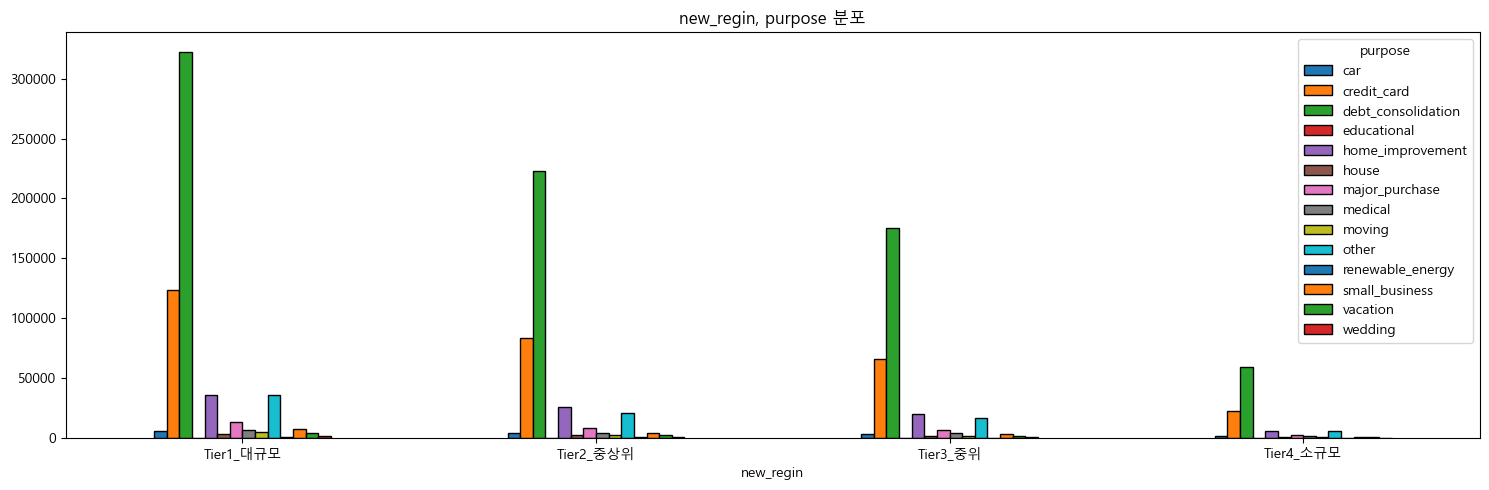

In [196]:
# GDP 기준 Tier 분류 (BEA 기준 대략적 GDP 순위)
# Tier 1: 상위 경제 대주 (GDP 상위 ~5개)
# Tier 2: 중상위 경제 주 (GDP 6~15위)
# Tier 3: 중위 경제 주 (GDP 16~30위)
# Tier 4: 소규모 경제 주 (GDP 31위 이하)


tier_map = {
    # Tier 1: GDP 1조+ 달러 또는 최상위 경제 규모
    'CA': 'Tier1_대규모', 'TX': 'Tier1_대규모', 'NY': 'Tier1_대규모',
    'FL': 'Tier1_대규모', 'IL': 'Tier1_대규모',

    # Tier 2: GDP 3000억~7000억 수준
    'PA': 'Tier2_중상위', 'OH': 'Tier2_중상위', 'NJ': 'Tier2_중상위',
    'GA': 'Tier2_중상위', 'WA': 'Tier2_중상위', 'MA': 'Tier2_중상위',
    'NC': 'Tier2_중상위', 'VA': 'Tier2_중상위', 'MI': 'Tier2_중상위',
    'CO': 'Tier2_중상위',

    # Tier 3: GDP 1500억~3000억 수준
    'MD': 'Tier3_중위', 'TN': 'Tier3_중위', 'AZ': 'Tier3_중위',
    'MN': 'Tier3_중위', 'IN': 'Tier3_중위', 'WI': 'Tier3_중위',
    'MO': 'Tier3_중위', 'CT': 'Tier3_중위', 'OR': 'Tier3_중위',
    'SC': 'Tier3_중위', 'LA': 'Tier3_중위', 'AL': 'Tier3_중위',
    'KY': 'Tier3_중위', 'OK': 'Tier3_중위', 'NV': 'Tier3_중위',
}

df['new_regin'] = df['addr_state'].map(tier_map).fillna('Tier4_소규모')


g_result = df.groupby(["new_regin", "purpose"]).size().reset_index(name="count")

display(g_result)
pivot = g_result.pivot(index="new_regin", columns="purpose", values="count")

pivot.plot(
    kind="bar",
    figsize=(15, 5),
    edgecolor="black"
)
plt.title("new_regin, purpose 분포")
plt.xticks(rotation=0)
plt.legend(title="purpose")
plt.tight_layout()

In [181]:
# 카이제곱 검정 
from scipy.stats import chi2_contingency
# 크로스탭 
ct_test_regin = pd.crosstab(df['new_regin'], df['target'])
ct_test_regin
chi2, p_value, dof, expected = chi2_contingency(ct_test_regin)

print(f"카이제곱 통계량: {chi2:.2f}")
print(f"자유도:         {dof}")
print(f"p-value:        {p_value:.4e}, 귀무가설 기각, 각 지역의 부도율은 차이가 존재" )


n = ct_test_regin.sum().sum()

r, c = ct_test_regin.shape
df_star = min(r - 1, c - 1)
cramers_v = np.sqrt(chi2 / (n * df_star))

print(f"Cramér's V:     {cramers_v:.4f}, 미미한 효과 ㅠㅠㅠㅠ 다른 기준점 찾아봄 ")

카이제곱 통계량: 172.36
자유도:         3
p-value:        3.9279e-37, 귀무가설 기각, 각 지역의 부도율은 차이가 존재
Cramér's V:     0.0113, 미미한 효과 ㅠㅠㅠㅠ 다른 기준점 찾아봄 


### 지역 변수에 대한 파생 피쳐 생성 
### 주 산업 기반 분류 
###  GDP 구성 비중에서 가장 지배적인 산업
### VA는 국방+IT 혼합

,industry_group_regin,purpose,count
0,관광_서비스,car,1440
1,관광_서비스,credit_card,25596
2,관광_서비스,debt_consolidation,70268
3,관광_서비스,educational,36
4,관광_서비스,home_improvement,9077
...,...,...,...
107,제조_산업,other,12583
108,제조_산업,renewable_energy,124
109,제조_산업,small_business,2250
110,제조_산업,vacation,1316


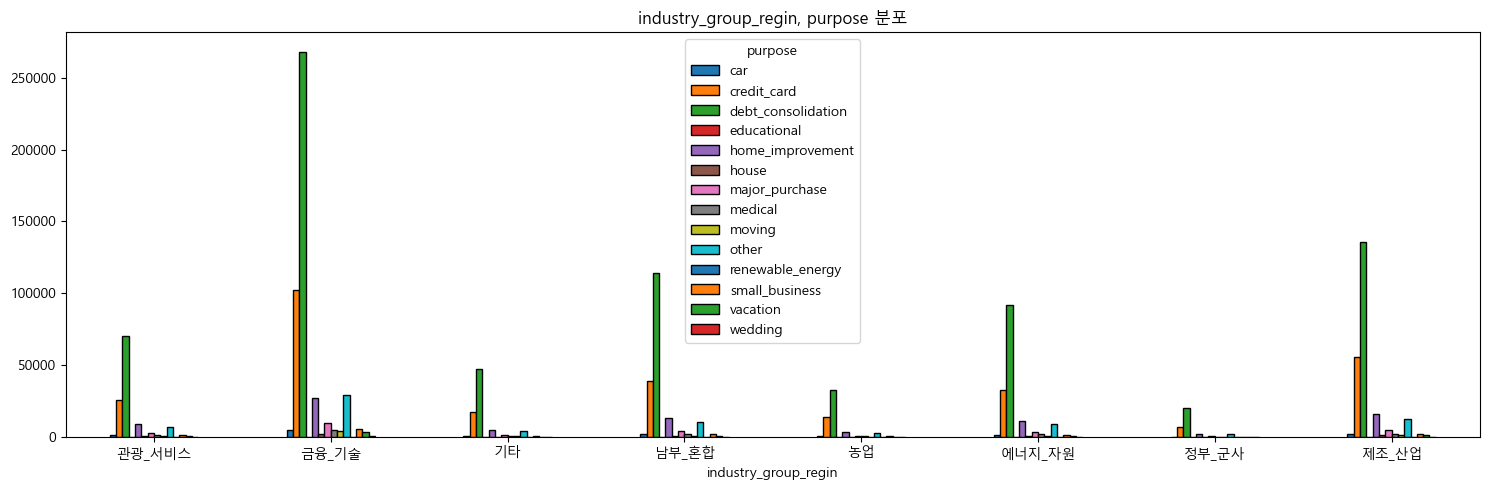

In [7]:
industry_map = {
    # 금융·기술 중심 (Finance & Tech Hub)
    'CA': '금융_기술', 'NY': '금융_기술', 'MA': '금융_기술',
    'WA': '금융_기술', 'NJ': '금융_기술', 'CT': '금융_기술',
    'CO': '금융_기술',

    # 에너지·자원 중심 (Energy & Resources)
    'TX': '에너지_자원', 'OK': '에너지_자원', 'LA': '에너지_자원',
    'AK': '에너지_자원', 'ND': '에너지_자원', 'WY': '에너지_자원',
    'NM': '에너지_자원', 'WV': '에너지_자원',

    # 제조·산업 벨트 (Manufacturing / Rust Belt)
    'MI': '제조_산업', 'OH': '제조_산업', 'IN': '제조_산업',
    'PA': '제조_산업', 'WI': '제조_산업', 'IL': '제조_산업',
    'MO': '제조_산업',

    # 농업 중심 (Agriculture)
    'IA': '농업', 'NE': '농업', 'KS': '농업',
    'SD': '농업', 'MN': '농업', 'ID': '농업',
    'MT': '농업', 'AR': '농업',

    # 관광·서비스 중심 (Tourism & Service)
    'FL': '관광_서비스', 'NV': '관광_서비스', 'HI': '관광_서비스',

    # 남부 혼합 경제 (Southern Mixed)
    'GA': '남부_혼합', 'NC': '남부_혼합', 'SC': '남부_혼합',
    'VA': '남부_혼합', 'TN': '남부_혼합', 'AL': '남부_혼합',
    'KY': '남부_혼합', 'MS': '남부_혼합',

    # 기타 (정부·군사 / 소규모 경제)
    'DC': '정부_군사', 'MD': '정부_군사',
    'AZ': '기타', 'OR': '기타', 'UT': '기타',
    'ME': '기타', 'NH': '기타', 'VT': '기타',
    'RI': '기타', 'DE': '기타',
}

df['industry_group_regin'] = df['addr_state'].map(industry_map).fillna('기타')

g_result = df.groupby(["industry_group_regin", "purpose"])["target"].count().reset_index(name="count")


display(g_result)
pivot = g_result.pivot(index="industry_group_regin", columns="purpose", values="count") 

pivot.plot(
    kind="bar",
    figsize=(15, 5),
    edgecolor="black"
)
plt.title("industry_group_regin, purpose 분포")
plt.xticks(rotation=0)
plt.legend(title="purpose")
plt.tight_layout()

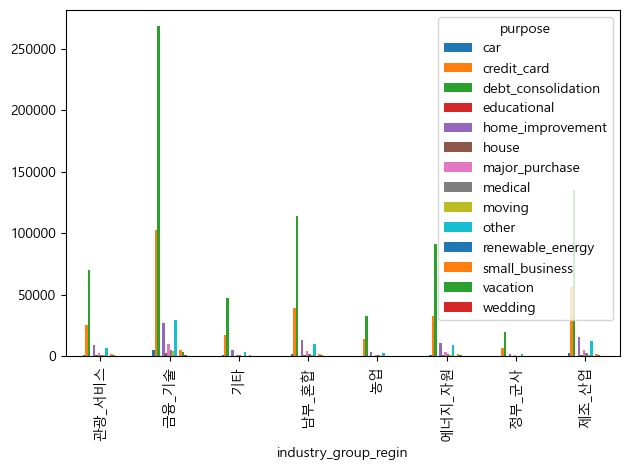

In [9]:
# 피벗 테이블로 보기 (A x B 교차표)
df.pivot_table(index="industry_group_regin", columns="purpose", values="target", aggfunc="count").plot(kind="bar")
plt.tight_layout()
plt.show()

In [193]:
# 카이제곱 검정 
# 크로스탭 
ct_test_indu = pd.crosstab(df['industry_group_regin'], df['target'])
ct_test_indu
chi2, p_value, dof, expected = chi2_contingency(ct_test_indu)

print(f"카이제곱 통계량: {chi2:.2f}")
print(f"자유도:         {dof}")
print(f"p-value:        {p_value:.4e}, 귀무가설 기각, 각 지역의 부도율은 차이가 존재" )


n = ct_test_indu.sum().sum()

r, c = ct_test_indu.shape
df_star = min(r - 1, c - 1)
cramers_v = np.sqrt(chi2 / (n * df_star))

small = 0.1 / np.sqrt(df_star)
medium = 0.3 / np.sqrt(df_star)
large = 0.5 / np.sqrt(df_star)

print(f"Cramér's V:     {cramers_v:.3f}, 무시할 수준")
print(small, medium, large) 


카이제곱 통계량: 560.38
자유도:         7
p-value:        8.2289e-117, 귀무가설 기각, 각 지역의 부도율은 차이가 존재
Cramér's V:     0.020, 무시할 수준
0.1 0.3 0.5


# 다시 시작 

In [26]:
df.groupby("target")["dti"].agg(
    mean = "mean", 
    median = "median", 
    count ="count"
).reset_index()

,target,mean,median,count
0,0.0,17.811664,17.11,1076446
1,1.0,20.170763,19.76,268528


In [ ]:
# 이상치 발견 
df.loc[df["dti"]<0, "dti"]

# dit 가 0 이라는건 기존 부채 상환액이 0 이라는 점

df = df.loc[df["dti"]>=0].copy()

df.loc[df["dti"]<0, "dti"].count()

np.int64(0)

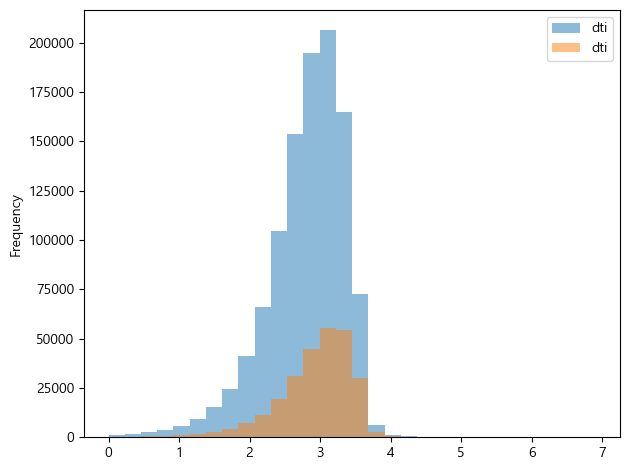

In [ ]:
# dti 탐색 log 변환 후 
for group, data in df.groupby("target")["dti"]: 
    np.log1p(data).plot(kind="hist", alpha= 0.5, bins=30, legend= group)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df["dti"].mean()

np.float64(19.085536923187668)

In [ ]:
np.expm1(3)
# 변환은 잘됨

np.float64(19.085536923187668)

In [56]:
from scipy import stats

group_a= df[df["target"] == 0]["dti"]
group_b =df[df["target"] == 1]["dti"]

stat, p = stats.mannwhitneyu(
    x=group_a,
    y=group_b,
    alternative='two-sided'
)
print(f"p-value: {p} ")
n1, n2 = len(group_a), len(group_b)
r = 1 - (2 * stat) / (n1 * n2)
print(f"효과크기: {r},작은 효과" )


p-value: 0.0 
효과크기: 0.15417552884179875,작은 효과


# 신용 점수 

In [ ]:
# 대출 시점시 신용 점수 
# 상한- 하안 
df["range_fico"] =df["fico_range_high"] - df["fico_range_low"]
df["range_fico"].value_counts()
#  4~ 5 라는 일정한 범위임 
# 따라서 하나의 값을 대표값으로 선택해서 보면 될듯 
# fico_range_high 을 대표로 탐색

range_fico
4.0    1344789
5.0        185
Name: count, dtype: int64

In [65]:
df.groupby("target")["fico_range_high"].agg(
    mean = "mean", 
    median = "median", 
    count ="count"
).reset_index()

,target,mean,median,count
0,0.0,702.261419,694.0,1076446
1,1.0,691.848843,684.0,268528


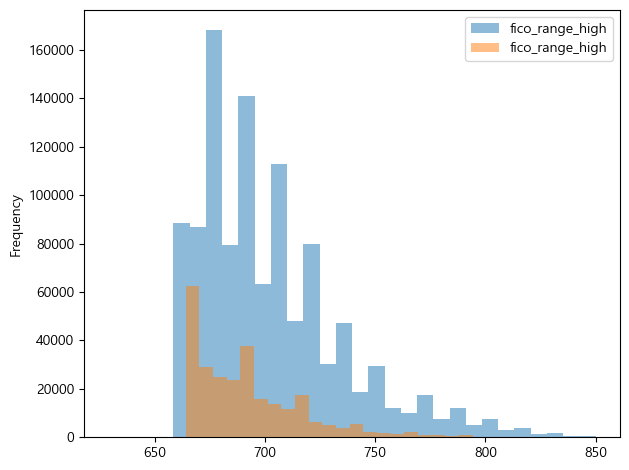

In [ ]:

for group, data in df.groupby("target")["fico_range_high"]: 
    data.plot(kind="hist", alpha= 0.5, bins=30, legend= group)
plt.legend()
plt.tight_layout()
plt.show()

# 잘단점이 보임 
# 특정 신용점수 이하는 대출이 거부 되었을 듯 

In [75]:
from scipy import stats

group_a= df[df["target"] == 0]["fico_range_high"]
group_b =df[df["target"] == 1]["fico_range_high"]

stat, p = stats.mannwhitneyu(
    x=group_a,
    y=group_b,
    alternative='two-sided'
)
print(f"p-value: {p} ")
n1, n2 = len(group_a), len(group_b)
r = 1 - (2 * stat) / (n1 * n2)
print(f"효과크기: {r},작은 효과, 부도그룹이 완납그룹 보다 높은 순위 경향 , 부도그룹의 대출 당시 신용 점수가 전반적으로 더 크다 사용 가능할듯?" )

p-value: 0.0 
효과크기: -0.18676461902607921,작은 효과, 부도그룹이 완납그룹 보다 높은 순위 경향 , 부도그룹의 대출 당시 신용 점수가 전반적으로 더 크다 사용 가능할듯?


# 차입자의 최초 신용계좌 개설일
### earliest_cr_line
## 파생 피쳐 신용 이력의 총수 
- 최초 시용 카드 개설일 - 대출 날 = 대출발급 당시까지 총 신용 이력 길이

In [107]:
df["earliest_cr_line"].isnull().sum()
# 결측치 없음
df["earliest_cr_line_dt"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")
df["issue_d_dt"]= pd.to_datetime(df["issue_d"], errors="coerce")
df["total_credit_day"] = (df["issue_d_dt"] - df["earliest_cr_line_dt"]).dt.days

df["total_credit_day"]

0           4505
1           5844
2           5600
4           6392
5          10288
           ...  
2260688     4475
2260690     5328
2260691     1949
2260692     7001
2260697     6302
Name: total_credit_day, Length: 1344974, dtype: int64

In [108]:
# 이상 탐지 
df["total_credit_day"].describe()
# 0이거나 음수인 값 없음   
# 최소 1095일 

count    1.344974e+06
mean     5.938904e+03
std      2.741660e+03
min      1.095000e+03
25%      4.108000e+03
50%      5.387000e+03
75%      7.305000e+03
max      3.040700e+04
Name: total_credit_day, dtype: float64

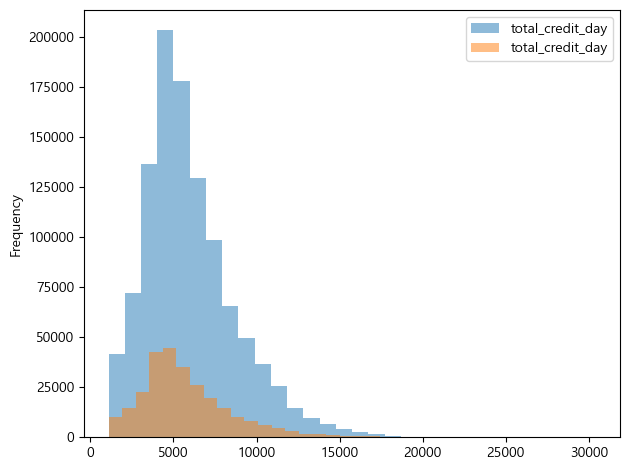

In [106]:
df.groupby("target")["total_credit_day"].agg(
    mean = "mean", 
    median = "median", 
    count ="count"
).reset_index()

for group, data in df.groupby("target")["total_credit_day"]: 
    data.plot(kind="hist", alpha= 0.5, bins=30, legend= group)
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
from scipy import stats

group_a= df[df["target"] == 0]["total_credit_day"]
group_b =df[df["target"] == 1]["total_credit_day"]

stat, p = stats.mannwhitneyu(
    x=group_a,
    y=group_b,
    alternative='two-sided'
)
print(f"p-value: {p} ")
n1, n2 = len(group_a), len(group_b)
r = 1 - (2 * stat) / (n1 * n2)
print(f"효과크기: {r},미미한 효과" )

p-value: 0.0 
효과크기: -0.056074252247762635,작은 효과


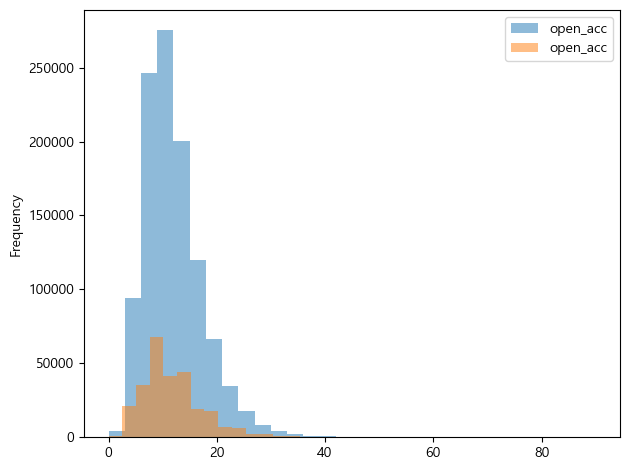

p-value: 0.0000 
효과크기: 0.03940724153852049,작은 효과, 


In [141]:
# open_acc 신용 카드 수

df.groupby("target")["open_acc"].agg(
    mean = "mean", 
    median = "median", 
    count ="count"
).reset_index()

for group, data in df.groupby("target")["open_acc"]: 
    data.plot(kind="hist", alpha= 0.5, bins=30, legend= group)
plt.legend()
plt.tight_layout()
plt.show()

from scipy import stats

group_a= df[df["target"] == 0]["open_acc"]
group_b =df[df["target"] == 1]["open_acc"]

stat, p = stats.mannwhitneyu(
    x=group_a,
    y=group_b,
    alternative='two-sided'
)
print(f"p-value: {p:.4f} ")
n1, n2 = len(group_a), len(group_b)
r = 1 - (2 * stat) / (n1 * n2)
print(f"효과크기: {r},작은 효과, " )

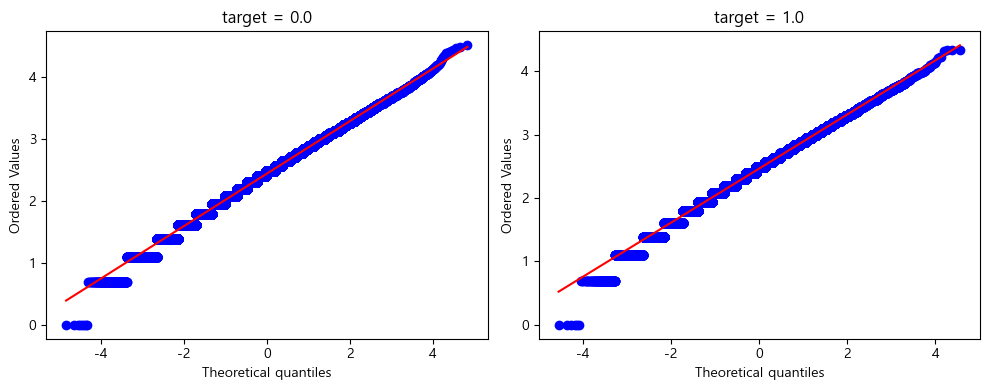

p-value: 0.0000 
Cohen's d: 0.0695 (작은 효과)


In [149]:
# 로그로 정규성 변환후 테스트 
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (group, data) in zip(axes, df.groupby("target")["open_acc"]):
    stats.probplot(np.log1p(data), plot=ax)
    ax.set_title(f"target = {group}")

plt.tight_layout()
plt.show()

group_a= df[df["target"] == 0]["open_acc"]
group_b =df[df["target"] == 1]["open_acc"]

t_stat, p_value = stats.ttest_ind(
    a=group_a,           
    b=group_b,          
    equal_var=False,    
    alternative='two-sided'
)

print(f"p-value: {p_value:.4f} ")
# 독립표본 (이등분 가정시 Welch's ) 단순 평균

def cohen_d(group_a, group_b):
    s_avg = np.sqrt((np.var(group_a, ddof=1) + np.var(group_b, ddof=1)) / 2)
    d = abs(np.mean(group_a) - np.mean(group_b)) / s_avg
    
    label = (
        "작은 효과" if d < 0.2 else
        "중간 효과" if d < 0.5 else
        "큰 효과"
    )
    return d, label

# 사용
d, label = cohen_d(group_a, group_b)
print(f"Cohen's d: {d:.4f} ({label})")

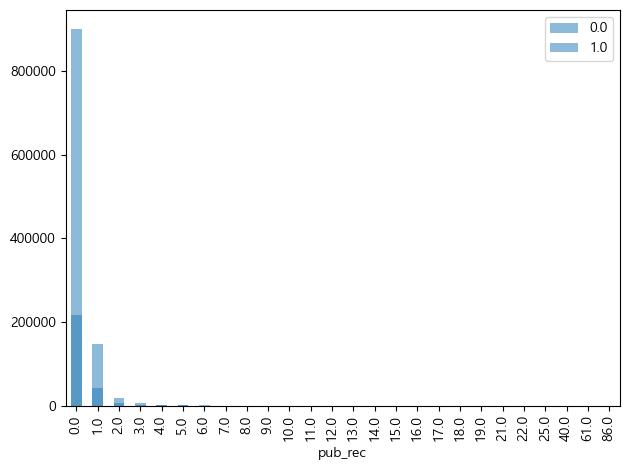

In [155]:
# pub_rec 공공 부정 기록 건수 

for group, data in df.groupby("target")["pub_rec"]:
    data.value_counts().sort_index().plot(kind="bar", alpha=0.5, label=group)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

df["pub_rec"].value_counts(normalize=True) * 100 

pub_rec
0.0     83.059226
1.0     14.182728
2.0      1.816615
3.0      0.550197
4.0      0.195543
5.0      0.094128
6.0      0.047287
7.0      0.021041
8.0      0.011896
9.0      0.006171
10.0     0.004238
11.0     0.002974
12.0     0.002007
13.0     0.001338
15.0     0.000669
18.0     0.000446
21.0     0.000446
14.0     0.000372
16.0     0.000372
19.0     0.000372
17.0     0.000223
28.0     0.000223
20.0     0.000223
49.0     0.000149
22.0     0.000149
24.0     0.000149
23.0     0.000074
86.0     0.000074
47.0     0.000074
46.0     0.000074
37.0     0.000074
40.0     0.000074
63.0     0.000074
34.0     0.000074
54.0     0.000074
25.0     0.000074
61.0     0.000074
Name: proportion, dtype: float64

# 특수 상태 컬럼 탐색 [실패, 폐기]

In [ ]:
# 채무 정산 여부 (Y/N)
# → 채무 정산 프로그램 참여 여부
df["debt_settlement_flag"].value_counts()

# 카이제곱 검정 
from scipy.stats import chi2_contingency
# 크로스탭 
ct_test= pd.crosstab(df['debt_settlement_flag'], df['target'])
display(ct_test)
chi2, p_value, dof, expected = chi2_contingency(ct_test)

print("기대빈도:\n", expected) 

print(f"카이제곱 통계량: {chi2:.2f}")
print(f"자유도:         {dof}")
print(f"p-value:        {p_value:.4e}, 귀무가설 기각, 각 지역의 부도율은 차이가 존재" )


n = ct_test.sum().sum()

r, c = ct_test.shape
df_star = min(r - 1, c - 1)
cramers_v = np.sqrt(chi2 / (n * df_star))

print(f"Cramér's V:     {cramers_v:.4f}, 오호 중간 효과 나이수 ")

target,0.0,1.0
debt_settlement_flag,,
N,1076441,235254
Y,5,33274


기대빈도:
 [[1049811.24986059  261883.75013941]
 [  26634.75013941    6644.24986059]]
카이제곱 통계량: 136733.39
자유도:         1
p-value:        0.0000e+00, 귀무가설 기각, 각 지역의 부도율은 차이가 존재
Cramér's V:     0.3188, 오호 중간 효과 나이수 


In [135]:
test= df[df["debt_settlement_flag_date"].notna()] 
test[["issue_d","debt_settlement_flag_date"]]

,issue_d,debt_settlement_flag_date
68,Dec-2015,Nov-2017
99,Dec-2015,May-2018
105,Dec-2015,Feb-2019
143,Dec-2015,May-2018
144,Dec-2015,Nov-2018
...,...,...
2260500,Oct-2016,Feb-2019
2260552,Oct-2016,Aug-2018
2260567,Oct-2016,Dec-2018
2260578,Oct-2016,Jan-2019


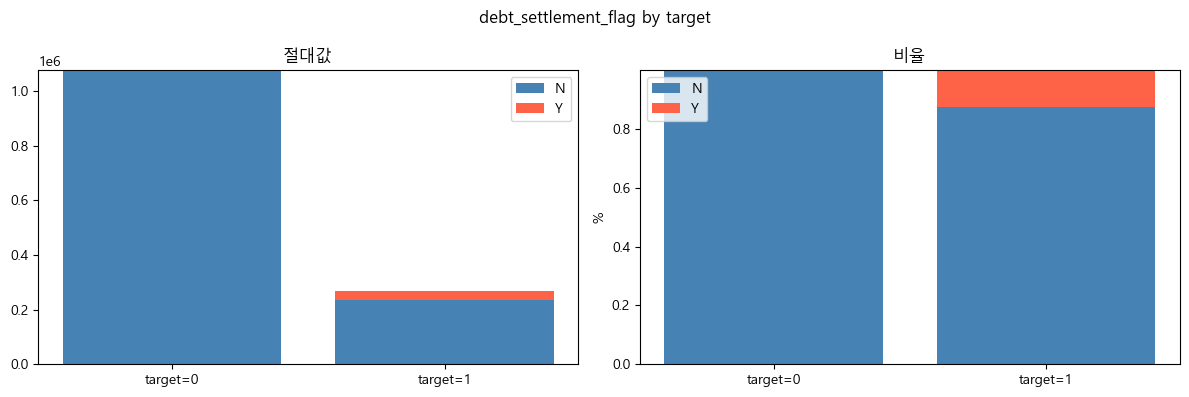

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

table = np.array([[1076441, 235254],
                  [5,        33274]])

# 비율로 변환 (절대값 차이가 너무 커서 비율이 더 유용)
table_pct = table / table.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 절대값
axes[0].bar(["target=0", "target=1"], table[0], label="N", color="steelblue")
axes[0].bar(["target=0", "target=1"], table[1], bottom=table[0], label="Y", color="tomato")
axes[0].set_title("절대값")
axes[0].legend()

# 비율
axes[1].bar(["target=0", "target=1"], table_pct[0], label="N", color="steelblue")
axes[1].bar(["target=0", "target=1"], table_pct[1], bottom=table_pct[0], label="Y", color="tomato")
axes[1].set_title("비율")
axes[1].set_ylabel("%")
axes[1].legend()

plt.suptitle("debt_settlement_flag by target")
plt.tight_layout()
plt.show()
## # 채무 정산 여부 (Y/N)
# → 채무 정산 프로그램 참여 자들은 부도 확률이 높다. 

In [128]:

# → 대출 지급 방식 (Cash, DirectPay)
df["disbursement_method"].value_counts()

# 카이제곱 검정 
from scipy.stats import chi2_contingency
# 크로스탭 
ct_test= pd.crosstab(df['disbursement_method'], df['target'])
display(ct_test)
chi2, p_value, dof, expected = chi2_contingency(ct_test)

print("기대빈도:\n", expected) 

print(f"카이제곱 통계량: {chi2:.2f}")
print(f"자유도:         {dof}")
print(f"p-value:        {p_value:.4f}, 귀무가설 기각 못함, " )


n = ct_test.sum().sum()

r, c = ct_test.shape
df_star = min(r - 1, c - 1)
cramers_v = np.sqrt(chi2 / (n * df_star))

print(f"Cramér's V:     {cramers_v:.4f}, 효과 없음 ")

target,0.0,1.0
disbursement_method,,
Cash,1070937,267143
DirectPay,5509,1385


기대빈도:
 [[1070928.40730007  267151.59269993]
 [   5517.59269993    1376.40730007]]
카이제곱 통계량: 0.06
자유도:         1
p-value:        0.8069, 귀무가설 기각 못함, 
Cramér's V:     0.0002, 효과 없음 
